# 분류 모델의 평가지표

## 오늘의 질문

**정확도(Accuracy) 하나만 보고 모델이 좋다고 판단할 수 있을까요?**

지난 시간 ML_파이프라인에서 타이타닉 생존 여부를 예측하는 모델을 만들고 정확도를 확인했습니다. 이번에는 같은 모델을 두고, 정확도 외에 어떤 지표를 함께 확인해야 하는지 살펴봅니다.

### 준비: 데이터와 모델

ML_파이프라인에서 사용한 것과 같은 방식으로 데이터를 정리하고, 같은 방식으로 학습·평가용 데이터를 나눕니다. 설정 코드를 외울 필요는 없습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from IPython.display import display

sns.set_style("whitegrid")

font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
korean_font = next((f for f in font_candidates if f in available_fonts), None)

if korean_font:
    plt.rcParams["font.family"] = korean_font
    plt.rcParams["font.sans-serif"] = [korean_font] + plt.rcParams["font.sans-serif"]
else:
    print("한글 폰트를 찾지 못했습니다. '맑은 고딕' 또는 '나눔고딕'을 설치한 뒤 커널을 재시작하세요.")

plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("Titanic-Dataset.csv")

y = df["Survived"]
X = df.drop(columns=["Survived"])
X = X.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X["Embarked"] = X["Embarked"].map({"S": 1, "C": 2, "Q": 3})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train["Age"] = X_train["Age"].fillna(X_train["Age"].median())
X_train["Embarked"] = X_train["Embarked"].fillna(X_train["Embarked"].mode()[0])
X_test["Age"] = X_test["Age"].fillna(X_train["Age"].median())
X_test["Embarked"] = X_test["Embarked"].fillna(X_train["Embarked"].mode()[0])

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"정확도: {accuracy:.3f}")

정확도: 0.804


## 1. 정확도만으로 충분할까요?

**왜 볼까요?** 정확도는 전체 중 맞춘 비율입니다. 그런데 한쪽 라벨이 훨씬 많은 데이터에서는 정확도가 높아도 실제로는 의미 있는 예측을 못하고 있을 수 있습니다.

타이타닉 데이터는 사망자(61%)가 생존자(39%)보다 많습니다. 아무 정보도 쓰지 않고 모든 승객을 '사망'으로 예측하면 정확도는 얼마가 나올까요?

In [2]:
baseline_accuracy = (y_test == 0).mean()
print(f"모두 사망으로 예측했을 때 정확도: {baseline_accuracy:.3f}")
print(f"모델 정확도: {accuracy:.3f}")

모두 사망으로 예측했을 때 정확도: 0.615
모델 정확도: 0.804


**확인:** 아무 정보도 쓰지 않은 예측도 정확도가 낮지 않게 나옵니다. 모델의 정확도가 이 기준보다 얼마나 높은지를 함께 봐야 모델이 실제로 도움이 되는지 판단할 수 있습니다.

정확도 하나로는 모델이 **어떤 종류의 예측을 틀리는지**는 알 수 없습니다. 이를 확인하는 방법이 혼동행렬입니다.

## 2. 혼동행렬(Confusion Matrix)

**왜 볼까요?** 예측과 실제 값을 표로 나누어, 어떤 조합에서 틀렸는지 확인합니다.

- 가로축: 모델이 예측한 값
- 세로축: 실제 값
- 대각선: 맞춘 경우, 대각선 밖: 틀린 경우

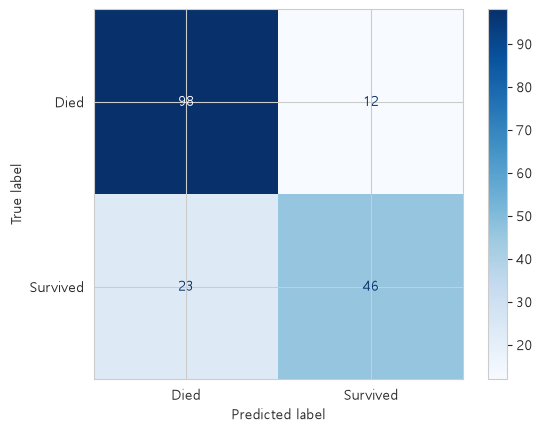

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Died", "Survived"], cmap="Blues"
)
plt.show()

**확인:** 표의 네 칸은 각각 이름이 있습니다.

| | 예측: 사망 | 예측: 생존 |
|---|---|---|
| **실제: 사망** | True Negative (TN) | False Positive (FP) |
| **실제: 생존** | False Negative (FN) | True Positive (TP) |

이 모델은 사망자는 대부분 맞추지만(TN이 많음), 생존자 중 상당수를 사망으로 잘못 예측합니다(FN이 많음). 정확도만 보면 이 차이가 드러나지 않습니다.

## 3. 정밀도(Precision)와 재현율(Recall)

**왜 볼까요?** 혼동행렬의 네 값을 하나의 숫자로 요약한 지표입니다.

- **정밀도:** 모델이 '생존'이라고 예측한 사람 중, 실제로 생존한 비율. `TP / (TP + FP)`
- **재현율:** 실제 생존자 중, 모델이 '생존'이라고 맞춘 비율. `TP / (TP + FN)`

두 지표는 같은 방향으로 움직이지 않을 수 있습니다.

In [4]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"정밀도: {precision:.3f}")
print(f"재현율: {recall:.3f}")

정밀도: 0.793
재현율: 0.667


**확인:** 재현율이 정밀도보다 낮게 나왔다면, 실제 생존자 중 놓치는 비율이 더 크다는 뜻입니다. 앞서 혼동행렬에서 본 FN(생존자를 사망으로 잘못 예측)이 많다는 관찰과 같은 내용을 숫자로 확인한 것입니다.

어떤 지표를 더 중요하게 볼지는 상황에 따라 다릅니다. 예를 들어 질병 진단에서는 실제 환자를 놓치지 않는 것(재현율)이, 스팸 메일 분류에서는 정상 메일을 스팸으로 잘못 보내지 않는 것(정밀도)이 더 중요할 수 있습니다.

## 4. F1 score

**왜 볼까요?** 정밀도와 재현율을 하나의 숫자로 함께 보고 싶을 때 사용하는 지표입니다. 두 값의 조화평균으로 계산합니다.

In [5]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1:.3f}")
print(f"정확도: {accuracy:.3f}")

F1 score: 0.724
정확도: 0.804


**확인:** F1 score가 정확도보다 낮게 나왔습니다. 모델이 두 라벨(생존/사망)을 균일하게 잘 맞춘다면 정확도와 F1 score는 비슷하게 나옵니다. 차이가 크다는 것은 한쪽 라벨에서 더 많이 틀리고 있다는 신호입니다.

## 5. 예측 확률과 임계값(Threshold)

**왜 볼까요?** 모델은 사실 0 또는 1이 아니라 '생존할 확률'을 계산하고, 그 확률이 0.5보다 크면 '생존'으로 분류합니다. 이 기준값(임계값)을 바꾸면 정밀도와 재현율이 어떻게 달라지는지 확인합니다.

In [6]:
y_proba = model.predict_proba(X_test)[:, 1]

for threshold in [0.3, 0.5, 0.7]:
    y_pred_t = (y_proba >= threshold).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    print(f"임계값 {threshold} → 정밀도 {p:.3f}, 재현율 {r:.3f}")

임계값 0.3 → 정밀도 0.655, 재현율 0.797
임계값 0.5 → 정밀도 0.793, 재현율 0.667
임계값 0.7 → 정밀도 0.895, 재현율 0.493


**확인:** 임계값을 낮추면 모델이 '생존'으로 더 쉽게 판단하게 되어 재현율은 올라가고 정밀도는 내려갑니다. 반대로 임계값을 높이면 정밀도는 올라가고 재현율은 내려갑니다. 하나를 무한정 올릴 수는 없고, 상황에 맞는 지점을 선택해야 합니다.

## 6. ROC curve

**왜 볼까요?** 임계값을 0부터 1까지 바꿔가며 True Positive Rate(재현율)와 False Positive Rate가 어떻게 변하는지 한 번에 보여주는 그래프입니다.

- 가로축: False Positive Rate — 실제 사망자 중 '생존'으로 잘못 예측한 비율
- 세로축: True Positive Rate — 실제 생존자 중 '생존'으로 맞게 예측한 비율
- 왼쪽 위 모서리에 가까울수록 좋은 모델, 대각선에 가까우면 무작위 예측과 다르지 않다는 뜻입니다.

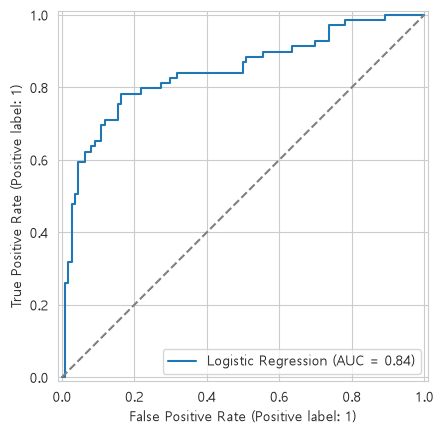

In [7]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba, name="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.show()

**확인:** 그래프 아래 면적(AUC)이 1에 가까울수록 좋은 모델입니다. AUC 0.5는 동전 던지기와 다르지 않다는 뜻입니다.

## 7. 분석할 오류 정하기: 생존자를 사망으로 예측한 경우

이번에는 실제 생존자를 사망으로 잘못 예측한 경우(FN)에 집중합니다. 앞에서 사용한 기본 모델의 예측(`y_pred`, 생존 판단 기준 0.5)을 그대로 살펴봅니다.

**왜 볼까요?** 재현율은 실제 생존자 중 맞춘 비율입니다. 그 반대로 놓친 사람이 몇 명인지 확인하고, 어떤 승객에게 이런 오류가 나타나는지 살펴보겠습니다.

분석표의 한 행은 평가용 승객 한 명입니다. 원본 승객 정보에 실제 값과 예측 결과를 연결한 뒤, **실제로 생존한 사람만** 골라냅니다. 원본과 모델의 입력 자료는 바꾸지 않습니다.

In [8]:
survivor_results = df.loc[y_test.index, ["Sex", "Pclass", "Age", "Fare"]].copy()
survivor_results["실제 생존 여부"] = y_test
survivor_results["예측 생존 여부"] = y_pred
survivor_results = survivor_results.loc[survivor_results["실제 생존 여부"] == 1].copy()
survivor_results["놓침"] = survivor_results["예측 생존 여부"] == 0
survivor_results["예측 결과"] = survivor_results["놓침"].map(
    {False: "생존으로 맞춤", True: "사망으로 놓침"}
)

survivor_count = len(survivor_results)
missed_count = int(survivor_results["놓침"].sum())
print(f"평가용 실제 생존자: {survivor_count}명")
print(f"생존으로 맞춘 사람: {survivor_count - missed_count}명")
print(f"사망으로 놓친 사람: {missed_count}명 ({missed_count / survivor_count:.1%})")

평가용 실제 생존자: 69명
생존으로 맞춘 사람: 46명
사망으로 놓친 사람: 23명 (33.3%)


**확인:** 놓친 비율은 `1 − 재현율`입니다. 이제 목표를 **“실제 생존자를 놓치는 경우를 줄이기”**로 정하고, 맞춘 생존자와 놓친 생존자 사이에 어떤 차이가 있는지 살펴봅니다.

생존자 수가 사망자 수보다 적다는 사실만으로 이 오류의 원인을 정할 수는 없습니다.

## 8. 같은 생존자 안에서 맞춘 경우와 놓친 경우 비교하기

성별을 예로 비교표와 그래프를 읽어봅니다. 비교 항목을 `Pclass`로 바꾸면 객실 등급별로도 확인할 수 있습니다.

**왜 볼까요?** 놓친 사람 수만 보면 사람이 많은 그룹이 더 문제가 있는 것처럼 보일 수 있습니다. **각 그룹의 실제 생존자 수와 그중 놓친 비율**을 함께 봅니다. 사망자는 이번 비교에 포함하지 않습니다.

- `Sex`: 성별, `Pclass`: 객실 등급(1·2·3등급).
- 표의 인원 단위는 명, 놓친 비율의 단위는 %입니다.
- 그래프의 가로축은 선택한 그룹, 세로축은 해당 그룹의 실제 생존자 중 놓친 비율입니다. 모든 막대는 같은 의미이며, 높을수록 생존자를 더 자주 놓쳤다는 뜻입니다.

,실제 생존자(명),맞춘 사람(명),놓친 사람(명),놓친 비율(%)
성별,,,,
여성,45,43,2,4.4
남성,24,3,21,87.5


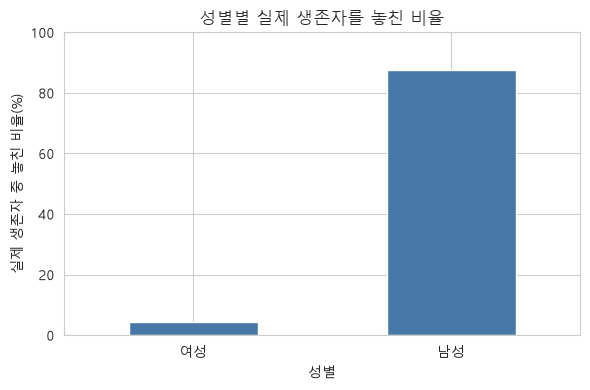

In [9]:
compare_column = "Sex"  # "Sex" 또는 "Pclass"로 바꿔 비교합니다.

column_labels = {"Sex": "성별", "Pclass": "객실 등급"}
value_labels = {
    "Sex": {"female": "여성", "male": "남성"},
    "Pclass": {1: "1등급", 2: "2등급", 3: "3등급"},
}

survivor_summary = survivor_results.groupby(compare_column)["놓침"].agg(
    생존자수="size", 놓친수="sum"
)
survivor_summary["맞춘수"] = survivor_summary["생존자수"] - survivor_summary["놓친수"]
survivor_summary["놓친 비율(%)"] = (
    survivor_summary["놓친수"] / survivor_summary["생존자수"] * 100
)
survivor_summary = survivor_summary.rename(
    index=value_labels[compare_column],
    columns={"생존자수": "실제 생존자(명)", "맞춘수": "맞춘 사람(명)", "놓친수": "놓친 사람(명)"},
)[["실제 생존자(명)", "맞춘 사람(명)", "놓친 사람(명)", "놓친 비율(%)"]]
survivor_summary.index.name = column_labels[compare_column]
display(survivor_summary.round(1))

ax = survivor_summary["놓친 비율(%)"].plot.bar(
    figsize=(6, 4), color="#4878A8", rot=0
)
ax.set(title=f"{column_labels[compare_column]}별 실제 생존자를 놓친 비율",
       xlabel=column_labels[compare_column], ylabel="실제 생존자 중 놓친 비율(%)", ylim=(0, 100))
plt.tight_layout()
plt.show()

**확인:** 어느 그룹에서 생존자를 놓친 비율이 더 높나요? 표에서 그 비율의 바탕이 된 실제 생존자 수도 함께 확인하세요. 인원이 적으면 한두 명의 결과로 비율이 크게 달라질 수 있습니다.

그룹 사이의 차이는 **이 평가 자료에서 모델이 어떤 생존자를 더 자주 놓쳤는지** 보여줍니다. 그 항목 자체가 오류의 원인이라고 확정한 것은 아닙니다. 다음 분석에서는 관심 그룹의 다른 정보도 함께 살펴볼 수 있습니다.

## 9. 놓친 남성 생존자는 몇 살일까?

앞에서 남성 생존자 24명 중 21명을 놓쳤습니다. 이번에는 남성의 나이를 살펴봅니다. 12세 미만과 그 이상으로 나누고, 원본에 나이가 없는 사람은 따로 표시합니다.

표의 한 행은 나이 그룹이고, 숫자는 모두 사람 수(명)입니다. 같은 그룹 안에서 맞춘 사람과 놓친 사람을 비교하세요.

In [10]:
child_age = 12  # 이번에 어린이로 묶어 볼 나이: 12세 미만

male_survivors = survivor_results.loc[survivor_results["Sex"] == "male"].copy()
male_survivors["나이 그룹"] = np.where(
    male_survivors["Age"] < child_age, f"{child_age}세 미만", f"{child_age}세 이상"
)
male_survivors.loc[male_survivors["Age"].isna(), "나이 그룹"] = "나이 없음"

age_summary = male_survivors.groupby("나이 그룹")["놓침"].agg(
    생존자수="size", 놓친수="sum"
)
age_summary["맞춘수"] = age_summary["생존자수"] - age_summary["놓친수"]
age_summary = age_summary.rename(columns={
    "생존자수": "실제 생존자(명)", "맞춘수": "맞춘 사람(명)", "놓친수": "놓친 사람(명)"
})
display(age_summary[["실제 생존자(명)", "맞춘 사람(명)", "놓친 사람(명)"]])

,실제 생존자(명),맞춘 사람(명),놓친 사람(명)
나이 그룹,,,
12세 미만,5,1,4
12세 이상,15,2,13
나이 없음,4,0,4


**확인:** 12세 미만 남성 생존자도 5명 중 4명을 놓쳤습니다.

그렇다면 **학습 자료에서 남성 어린이와 그보다 나이 많은 남성의 생존 비율은 다를까요?** 이번에는 사망자도 포함해서 비교합니다. 생존자만 보면 나이가 생존 여부를 구분하는 데 도움이 되는지 알 수 없기 때문입니다.

아래 표의 한 행은 학습용 남성 승객의 나이 그룹입니다. 인원은 명, 생존 비율은 각 그룹에서 살아남은 사람의 비율(%)입니다. 나이가 없는 사람은 따로 표시합니다.

In [11]:
train_males = df.loc[y_train.index, ["Sex", "Age", "Survived"]].copy()
train_males = train_males.loc[train_males["Sex"] == "male"].copy()
train_males["나이 그룹"] = np.where(
    train_males["Age"] < child_age, f"{child_age}세 미만", f"{child_age}세 이상"
)
train_males.loc[train_males["Age"].isna(), "나이 그룹"] = "나이 없음"

train_age_summary = train_males.groupby("나이 그룹")["Survived"].agg(
    승객수="size", 생존자수="sum"
)
train_age_summary["생존 비율(%)"] = (
    train_age_summary["생존자수"] / train_age_summary["승객수"] * 100
)
train_age_summary = train_age_summary.rename(columns={
    "승객수": "전체 승객(명)", "생존자수": "생존자(명)"
})
display(train_age_summary.round(1))

,전체 승객(명),생존자(명),생존 비율(%)
나이 그룹,,,
12세 미만,27,15,55.6
12세 이상,334,58,17.4
나이 없음,98,12,12.2


**확인:** 학습 자료에서도 12세 미만 남성의 생존 비율이 더 높습니다. 어린이와 그 이상을 구분하는 것이 예측에 도움이 될 가능성이 있습니다. 다만 어린이 인원이 적고, 객실 등급 등 다른 차이도 있을 수 있습니다.

**가설:** 모델이 이 차이를 충분히 반영하지 못했을 수 있습니다. 나이는 이미 입력에 있으니, 이번에는 같은 나이 정보에 **‘어린이 여부’라는 표시를 덧붙여** 다시 학습해 보겠습니다. 이 표시가 실제로 도움이 되는지는 변경 전후 결과로 확인합니다.

## 10. 어린이 여부를 추가하면 더 잘 맞출까?

앞에서 본 나이 그룹의 차이를 모델에 알려주기 위해, 12세 미만이면 1, 그 이상이면 0인 **어린이 여부** 항목을 모든 승객에게 추가합니다. 모델 종류와 학습·평가용 승객, 생존 판단 기준(0.5)은 그대로 둡니다.

12세는 이번 비교를 위해 정한 기준입니다. 나이가 비어 있던 승객은 앞에서 채워 둔 나이를 사용합니다.

In [12]:
X_train_child = X_train.copy()
X_test_child = X_test.copy()
X_train_child["IsChild"] = (X_train_child["Age"] < child_age).astype(int)
X_test_child["IsChild"] = (X_test_child["Age"] < child_age).astype(int)

child_model = LogisticRegression(random_state=42, max_iter=1000)
child_model.fit(X_train_child, y_train)
y_pred_child = child_model.predict(X_test_child)

같은 승객들을 다시 예측했습니다. **관심을 둔 어린이와 남성 생존자를 덜 놓치는지** 먼저 보고, 전체 결과도 함께 확인합니다.

표의 ‘놓친 사람’은 실제 생존자를 사망으로 예측한 사람입니다. 정확도는 전체 승객 중 맞춘 비율(%)입니다.

In [13]:
male_mask = (df.loc[y_test.index, "Sex"] == "male") & (y_test == 1)
child_male_mask = male_mask & (df.loc[y_test.index, "Age"] < child_age)

comparison = {}
for name, prediction in [("추가 전", y_pred), ("추가 후", y_pred_child)]:
    comparison[name] = {
        f"{child_age}세 미만 남성 생존자 중 놓친 사람(명)": int((child_male_mask & (prediction == 0)).sum()),
        "남성 생존자 중 놓친 사람(명)": int((male_mask & (prediction == 0)).sum()),
        "전체 생존자 중 놓친 사람(명)": int(((y_test == 1) & (prediction == 0)).sum()),
        "사망자를 생존으로 잘못 예측한 사람(명)": int(((y_test == 0) & (prediction == 1)).sum()),
        "전체 정확도(%)": round((y_test == prediction).mean() * 100, 1),
    }
display(pd.DataFrame(comparison))

,추가 전,추가 후
12세 미만 남성 생존자 중 놓친 사람(명),4.0,4.0
남성 생존자 중 놓친 사람(명),21.0,21.0
전체 생존자 중 놓친 사람(명),23.0,24.0
사망자를 생존으로 잘못 예측한 사람(명),12.0,12.0
전체 정확도(%),80.4,79.9


**결과:** 어린이 여부를 추가해도 놓친 남성 어린이는 4명, 놓친 남성 생존자는 21명으로 그대로입니다. 전체에서 놓친 생존자는 23명에서 24명으로 늘었습니다.

**이번 시도는 개선에 도움이 되지 않았습니다.** 학습 자료에서 생존 비율에 차이가 있었지만, 그 구분을 입력에 추가하는 것만으로 예측이 좋아지지는 않았습니다.

다음에는 놓친 사람들의 객실 등급이나 동반 가족 정보를 더 살펴볼 수 있습니다. 여러 방법을 비교해 고를 때는 검증용 자료를 따로 쓰고, 최종 평가는 선택에 쓰지 않은 자료에서 합니다.